In [1]:
import os

folder = r"C:\Users\hp\Downloads\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1"

print(os.listdir(folder))

['mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1']


In [3]:
for root, dirs, files in os.walk(folder):
    print("FOLDER:", root)
    print("FILES:", files[:10])
    print()

FOLDER: C:\Users\hp\Downloads\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1
FILES: []

FOLDER: C:\Users\hp\Downloads\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1
FILES: ['LICENSE.txt', 'RECORDS', 'record_list.csv', 'SHA256SUMS.txt']

FOLDER: C:\Users\hp\Downloads\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\files
FILES: []

FOLDER: C:\Users\hp\Downloads\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\files\p10000032
FILES: []

FOLDER: C:\Users\hp\Downloads\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\files\p10000032\s100780919
FILES: ['100780919.dat', '100780919.hea']

FOLDER: C:\Use

In [5]:
print("Top-level contents:")
for item in os.listdir(folder):
    print(item)

Top-level contents:
mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1


In [7]:
import os

folder = (
    r"C:\Users\hp\Downloads\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1"
    r"\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1"
)

print(os.listdir(folder))

['files', 'LICENSE.txt', 'RECORDS', 'record_list.csv', 'SHA256SUMS.txt']


In [9]:
files_folder = os.path.join(folder, "files")

print(os.listdir(files_folder)[:20])

['p10000032', 'p10001217', 'p10001725', 'p10002428', 'p10002495', 'p10002930', 'p10003046', 'p10003400', 'p10004235', 'p10004422', 'p10004457', 'p10004720', 'p10004733', 'p10005348', 'p10005817', 'p10005866', 'p10006053', 'p10006580', 'p10007058', 'p10007795']


In [11]:
import os

for root, dirs, files in os.walk(files_folder):
    hea_files = [f for f in files if f.endswith(".hea")]

    if hea_files:
        print("Folder:", root)
        print("ECG:", hea_files[0])
        break

Folder: C:\Users\hp\Downloads\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\files\p10000032\s100780919
ECG: 100780919.hea


In [13]:
import wfdb
import os

ecg_folder = r"C:\Users\hp\Downloads\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\mimic-iv-ecg-demo-diagnostic-electrocardiogram-matched-subset-demo-0.1\files\p10000032\s100780919"

record = wfdb.rdrecord(
    os.path.join(ecg_folder, "100780919")
)

print("Leads:", record.sig_name)
print("Sampling frequency:", record.fs)
print("Shape:", record.p_signal.shape)

Leads: ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Sampling frequency: 500
Shape: (5000, 12)


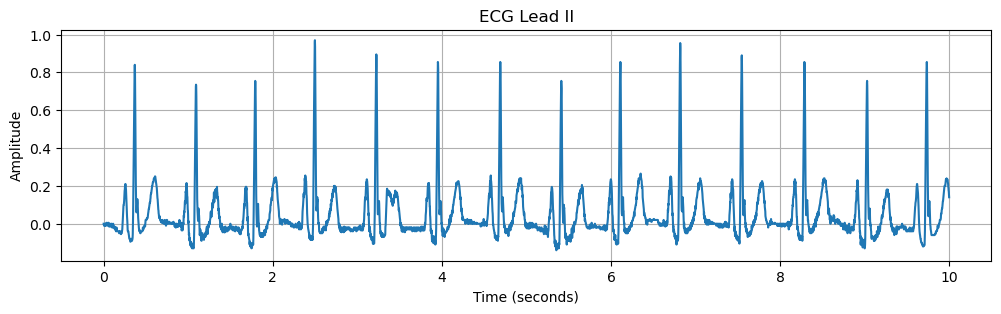

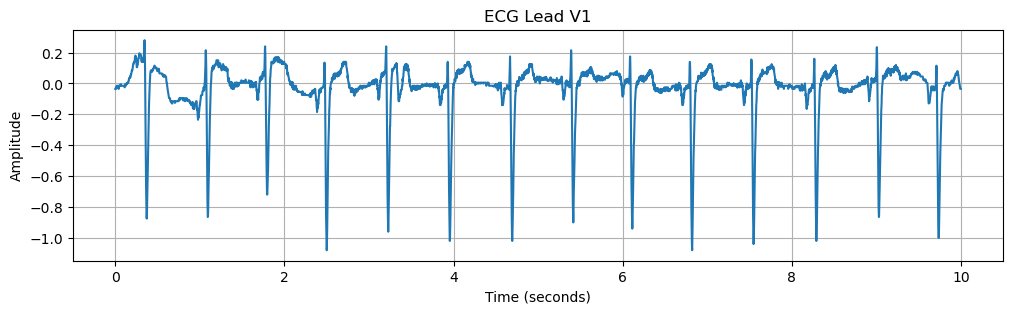

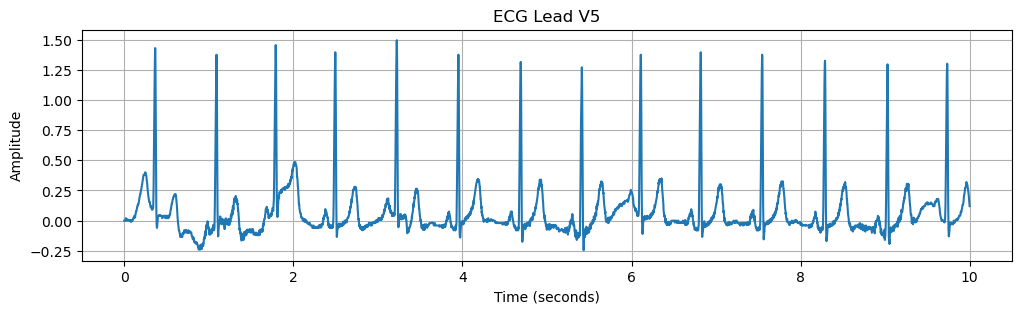

In [15]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(record.p_signal.shape[0]) / record.fs

for lead in ["II", "V1", "V5"]:
    i = record.sig_name.index(lead)

    plt.figure(figsize=(12, 3))
    plt.plot(time, record.p_signal[:, i])
    plt.title(f"ECG Lead {lead}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

In [17]:
import pandas as pd
import os

record_list_path = os.path.join(folder, "record_list.csv")

records = pd.read_csv(record_list_path)

print(records.shape)
print(records.columns.tolist())

records.head()

(659, 5)
['subject_id', 'study_id', 'file_name', 'ecg_time', 'path']


,subject_id,study_id,file_name,ecg_time,path
0,10000032,107143276,107143276,2180-07-23 08:44:24,files/p10000032/s107143276/107143276
1,10000032,102511170,102511170,2180-08-06 09:07:36,files/p10000032/s102511170/102511170
2,10000032,100780919,100780919,2180-07-23 09:54:32,files/p10000032/s100780919/100780919
3,10001217,105362569,105362569,2157-11-18 18:26:02,files/p10001217/s105362569/105362569
4,10001217,102172660,102172660,2157-11-20 09:08:38,files/p10001217/s102172660/102172660


In [19]:
records[records["study_id"] == 100780919]

,subject_id,study_id,file_name,ecg_time,path
2,10000032,100780919,100780919,2180-07-23 09:54:32,files/p10000032/s100780919/100780919


In [21]:
records.shape
records.columns.tolist()
records.head()

,subject_id,study_id,file_name,ecg_time,path
0,10000032,107143276,107143276,2180-07-23 08:44:24,files/p10000032/s107143276/107143276
1,10000032,102511170,102511170,2180-08-06 09:07:36,files/p10000032/s102511170/102511170
2,10000032,100780919,100780919,2180-07-23 09:54:32,files/p10000032/s100780919/100780919
3,10001217,105362569,105362569,2157-11-18 18:26:02,files/p10001217/s105362569/105362569
4,10001217,102172660,102172660,2157-11-20 09:08:38,files/p10001217/s102172660/102172660


In [23]:
import os
import wfdb
import numpy as np
import pandas as pd

features = []

for _, row in records.iterrows():

    record_path = os.path.join(
        folder,
        row["path"].replace("/", os.sep)
    )

    try:
        rec = wfdb.rdrecord(record_path)

        signal = rec.p_signal
        names = rec.sig_name

        row_features = {
            "subject_id": row["subject_id"],
            "study_id": row["study_id"]
        }

        for lead in ["II", "V1", "V5"]:

            if lead in names:
                i = names.index(lead)
                x = signal[:, i]

                row_features[f"{lead}_mean"] = np.nanmean(x)
                row_features[f"{lead}_std"] = np.nanstd(x)
                row_features[f"{lead}_min"] = np.nanmin(x)
                row_features[f"{lead}_max"] = np.nanmax(x)

        features.append(row_features)

    except Exception as e:
        print("Error:", row["study_id"], e)

feature_df = pd.DataFrame(features)

feature_df.head()

,subject_id,study_id,II_mean,II_std,II_min,II_max,V1_mean,V1_std,V1_min,V1_max,V5_mean,V5_std,V5_min,V5_max
0,10000032,107143276,0.035318,0.148429,-0.200,0.795,-0.031452,0.188106,-1.040,0.215,0.046797,0.266958,-0.615,1.515
1,10000032,102511170,0.026450,0.140970,-0.185,0.880,-0.023951,0.279642,-1.535,0.425,0.079278,0.244288,-0.385,1.360
2,10000032,100780919,0.045368,0.142229,-0.140,0.970,-0.026946,0.174311,-1.080,0.280,0.066700,0.221579,-0.245,1.495
3,10001217,105362569,0.048974,0.138568,-0.165,0.995,-0.033130,0.168639,-1.125,0.260,0.059333,0.219387,-0.365,1.575
4,10001217,102172660,0.042521,0.129099,-0.175,0.985,-0.036362,0.143032,-0.950,0.210,0.040285,0.158914,-0.340,1.305


In [25]:
print("Shape:", feature_df.shape)

print("\nMissing values:")
print(feature_df.isna().sum())

Shape: (659, 14)

Missing values:
subject_id    0
study_id      0
II_mean       0
II_std        0
II_min        0
II_max        0
V1_mean       0
V1_std        0
V1_min        0
V1_max        0
V5_mean       0
V5_std        0
V5_min        0
V5_max        0
dtype: int64


In [27]:
pip install scipy

In [29]:
from scipy.signal import find_peaks
import numpy as np

def extract_ecg_features(signal, fs):

    signal = np.asarray(signal)

    # remove NaNs
    valid = ~np.isnan(signal)
    signal = signal[valid]

    if len(signal) < fs * 2:
        return {
            "heart_rate": np.nan,
            "rr_mean": np.nan,
            "rr_std": np.nan,
            "r_peak_count": np.nan
        }

    # Simple R peak detection
    peaks, _ = find_peaks(
        signal,
        distance=int(0.4 * fs),
        prominence=0.2
    )

    if len(peaks) < 2:
        return {
            "heart_rate": np.nan,
            "rr_mean": np.nan,
            "rr_std": np.nan,
            "r_peak_count": len(peaks)
        }

    rr_intervals = np.diff(peaks) / fs

    heart_rate = 60 / np.mean(rr_intervals)

    return {
        "heart_rate": heart_rate,
        "rr_mean": np.mean(rr_intervals),
        "rr_std": np.std(rr_intervals),
        "r_peak_count": len(peaks)
    }

In [31]:
lead = "II"

i = record.sig_name.index(lead)

ecg = record.p_signal[:, i]

ecg_features = extract_ecg_features(
    ecg,
    record.fs
)

ecg_features

{'heart_rate': 83.27994875080077,
 'rr_mean': 0.7204615384615385,
 'rr_std': 0.014700158997650788,
 'r_peak_count': 14}

In [33]:
all_features = []

for _, row in records.iterrows():

    record_path = os.path.join(
        folder,
        row["path"].replace("/", os.sep)
    )

    try:
        rec = wfdb.rdrecord(record_path)

        signal = rec.p_signal
        names = rec.sig_name

        row_features = {
            "subject_id": row["subject_id"],
            "study_id": row["study_id"]
        }

        # Basic features from selected leads
        for lead in ["II", "V1", "V5"]:

            if lead in names:
                i = names.index(lead)
                x = signal[:, i]

                row_features[f"{lead}_mean"] = np.nanmean(x)
                row_features[f"{lead}_std"] = np.nanstd(x)
                row_features[f"{lead}_min"] = np.nanmin(x)
                row_features[f"{lead}_max"] = np.nanmax(x)

        # Heart rate + RR features from Lead II
        if "II" in names:
            i = names.index("II")
            ecg = signal[:, i]

            hr_features = extract_ecg_features(
                ecg,
                rec.fs
            )

            row_features.update(hr_features)

        all_features.append(row_features)

    except Exception as e:
        print("Error:", row["study_id"], e)

final_features = pd.DataFrame(all_features)

final_features.head()

,subject_id,study_id,II_mean,II_std,II_min,II_max,V1_mean,V1_std,V1_min,V1_max,V5_mean,V5_std,V5_min,V5_max,heart_rate,rr_mean,rr_std,r_peak_count
0,10000032,107143276,0.035318,0.148429,-0.200,0.795,-0.031452,0.188106,-1.040,0.215,0.046797,0.266958,-0.615,1.515,90.968161,0.659571,0.009597,15
1,10000032,102511170,0.026450,0.140970,-0.185,0.880,-0.023951,0.279642,-1.535,0.425,0.079278,0.244288,-0.385,1.360,100.146046,0.599125,0.007381,17
2,10000032,100780919,0.045368,0.142229,-0.140,0.970,-0.026946,0.174311,-1.080,0.280,0.066700,0.221579,-0.245,1.495,83.279949,0.720462,0.014700,14
3,10001217,105362569,0.048974,0.138568,-0.165,0.995,-0.033130,0.168639,-1.125,0.260,0.059333,0.219387,-0.365,1.575,66.964286,0.896000,0.021052,11
4,10001217,102172660,0.042521,0.129099,-0.175,0.985,-0.036362,0.143032,-0.950,0.210,0.040285,0.158914,-0.340,1.305,71.707953,0.836727,0.042197,12


In [35]:
print("Shape:", final_features.shape)

final_features[
    ["subject_id", "study_id",
     "heart_rate", "rr_mean",
     "rr_std", "r_peak_count"]
].head(10)

Shape: (659, 18)


,subject_id,study_id,heart_rate,rr_mean,rr_std,r_peak_count
0,10000032,107143276,90.968161,0.659571,0.009597,15
1,10000032,102511170,100.146046,0.599125,0.007381,17
2,10000032,100780919,83.279949,0.720462,0.014700,14
3,10001217,105362569,66.964286,0.896000,0.021052,11
4,10001217,102172660,71.707953,0.836727,0.042197,12
5,10001725,102147240,59.523810,1.008000,0.020199,10
6,10002428,104430624,110.917790,0.540941,0.002754,18
7,10002428,102144047,98.576123,0.608667,0.002385,16
8,10002428,106959793,105.677580,0.567765,0.002462,18
9,10002428,106183809,96.277279,0.623200,0.002713,16


In [37]:
final_features.isna().sum()

subject_id      0
study_id        0
II_mean         0
II_std          0
II_min          0
II_max          0
V1_mean         0
V1_std          0
V1_min          0
V1_max          0
V5_mean         0
V5_std          0
V5_min          0
V5_max          0
heart_rate      1
rr_mean         1
rr_std          1
r_peak_count    0
dtype: int64

In [39]:
final_features = final_features.dropna()

print(final_features.shape)
print(final_features.isna().sum())

(658, 18)
subject_id      0
study_id        0
II_mean         0
II_std          0
II_min          0
II_max          0
V1_mean         0
V1_std          0
V1_min          0
V1_max          0
V5_mean         0
V5_std          0
V5_min          0
V5_max          0
heart_rate      0
rr_mean         0
rr_std          0
r_peak_count    0
dtype: int64


In [41]:
clinical_folder = r"C:\Users\hp\Downloads\mimic-iv-clinical-database-demo-2.2"

In [43]:
import os

print(os.listdir(clinical_folder))

['mimic-iv-clinical-database-demo-2.2']


In [45]:
hosp_folder = os.path.join(clinical_folder, "hosp")

print(os.listdir(hosp_folder))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\hp\\Downloads\\mimic-iv-clinical-database-demo-2.2\\hosp'

In [47]:
import os

clinical_folder = r"C:\Users\hp\Downloads\mimic-iv-clinical-database-demo-2.2"

print(os.listdir(clinical_folder))

['mimic-iv-clinical-database-demo-2.2']


In [49]:
clinical_folder = (
    r"C:\Users\hp\Downloads\mimic-iv-clinical-database-demo-2.2"
    r"\mimic-iv-clinical-database-demo-2.2"
)

print(os.listdir(clinical_folder))

['demo_subject_id.csv', 'hosp', 'icu', 'LICENSE.txt', 'README.txt', 'SHA256SUMS.txt']


In [51]:
hosp_folder = os.path.join(clinical_folder, "hosp")

print(os.listdir(hosp_folder))

['admissions.csv.gz', 'diagnoses_icd.csv.gz', 'drgcodes.csv.gz', 'd_hcpcs.csv.gz', 'd_icd_diagnoses.csv.gz', 'd_icd_procedures.csv.gz', 'd_labitems.csv.gz', 'emar.csv.gz', 'emar_detail.csv.gz', 'hcpcsevents.csv.gz', 'labevents.csv.gz', 'microbiologyevents.csv.gz', 'omr.csv.gz', 'patients.csv.gz', 'pharmacy.csv.gz', 'poe.csv.gz', 'poe_detail.csv.gz', 'prescriptions.csv.gz', 'procedures_icd.csv.gz', 'provider.csv.gz', 'services.csv.gz', 'transfers.csv.gz']


In [53]:
for root, dirs, files in os.walk(
    r"C:\Users\hp\Downloads\mimic-iv-clinical-database-demo-2.2"
):
    if "hosp" in dirs:
        hosp_folder = os.path.join(root, "hosp")
        print("Found hosp folder:")
        print(hosp_folder)
        break

Found hosp folder:
C:\Users\hp\Downloads\mimic-iv-clinical-database-demo-2.2\mimic-iv-clinical-database-demo-2.2\hosp


In [55]:
print(os.listdir(hosp_folder))

['admissions.csv.gz', 'diagnoses_icd.csv.gz', 'drgcodes.csv.gz', 'd_hcpcs.csv.gz', 'd_icd_diagnoses.csv.gz', 'd_icd_procedures.csv.gz', 'd_labitems.csv.gz', 'emar.csv.gz', 'emar_detail.csv.gz', 'hcpcsevents.csv.gz', 'labevents.csv.gz', 'microbiologyevents.csv.gz', 'omr.csv.gz', 'patients.csv.gz', 'pharmacy.csv.gz', 'poe.csv.gz', 'poe_detail.csv.gz', 'prescriptions.csv.gz', 'procedures_icd.csv.gz', 'provider.csv.gz', 'services.csv.gz', 'transfers.csv.gz']


In [57]:
import pandas as pd
import os

patients = pd.read_csv(
    os.path.join(hosp_folder, "patients.csv.gz")
)

admissions = pd.read_csv(
    os.path.join(hosp_folder, "admissions.csv.gz")
)

print("Patients shape:", patients.shape)
print("Admissions shape:", admissions.shape)

print("\nPatients columns:")
print(patients.columns.tolist())

print("\nAdmissions columns:")
print(admissions.columns.tolist())

Patients shape: (100, 6)
Admissions shape: (275, 16)

Patients columns:
['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']

Admissions columns:
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']


In [59]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [61]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [63]:
patients.columns.tolist()
admissions.columns.tolist()

['subject_id',
 'hadm_id',
 'admittime',
 'dischtime',
 'deathtime',
 'admission_type',
 'admit_provider_id',
 'admission_location',
 'discharge_location',
 'insurance',
 'language',
 'marital_status',
 'race',
 'edregtime',
 'edouttime',
 'hospital_expire_flag']

In [65]:
records["ecg_time"] = pd.to_datetime(records["ecg_time"])

admissions["admittime"] = pd.to_datetime(admissions["admittime"])
admissions["dischtime"] = pd.to_datetime(admissions["dischtime"])

In [67]:
final_features = final_features.merge(
    records[["subject_id", "study_id", "ecg_time"]],
    on=["subject_id", "study_id"],
    how="left"
)

final_features.head()

,subject_id,study_id,II_mean,II_std,II_min,II_max,V1_mean,V1_std,V1_min,V1_max,V5_mean,V5_std,V5_min,V5_max,heart_rate,rr_mean,rr_std,r_peak_count,ecg_time
0,10000032,107143276,0.035318,0.148429,-0.200,0.795,-0.031452,0.188106,-1.040,0.215,0.046797,0.266958,-0.615,1.515,90.968161,0.659571,0.009597,15,2180-07-23 08:44:24
1,10000032,102511170,0.026450,0.140970,-0.185,0.880,-0.023951,0.279642,-1.535,0.425,0.079278,0.244288,-0.385,1.360,100.146046,0.599125,0.007381,17,2180-08-06 09:07:36
2,10000032,100780919,0.045368,0.142229,-0.140,0.970,-0.026946,0.174311,-1.080,0.280,0.066700,0.221579,-0.245,1.495,83.279949,0.720462,0.014700,14,2180-07-23 09:54:32
3,10001217,105362569,0.048974,0.138568,-0.165,0.995,-0.033130,0.168639,-1.125,0.260,0.059333,0.219387,-0.365,1.575,66.964286,0.896000,0.021052,11,2157-11-18 18:26:02
4,10001217,102172660,0.042521,0.129099,-0.175,0.985,-0.036362,0.143032,-0.950,0.210,0.040285,0.158914,-0.340,1.305,71.707953,0.836727,0.042197,12,2157-11-20 09:08:38


In [69]:
ecg_adm = final_features.merge(
    admissions,
    on="subject_id",
    how="inner"
)

ecg_adm = ecg_adm[
    (ecg_adm["ecg_time"] >= ecg_adm["admittime"]) &
    (ecg_adm["ecg_time"] <= ecg_adm["dischtime"])
].copy()

print(ecg_adm.shape)

ecg_adm[
    ["subject_id", "study_id", "ecg_time",
     "hadm_id", "admittime", "dischtime",
     "hospital_expire_flag"]
].head(10)

(364, 34)


,subject_id,study_id,ecg_time,hadm_id,admittime,dischtime,hospital_expire_flag
6,10000032,102511170,2180-08-06 09:07:36,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,0
14,10001217,102172660,2157-11-20 09:08:38,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,0
17,10002428,104430624,2156-04-20 09:31:52,28662225,2156-04-12 14:16:00,2156-04-29 16:26:00,0
31,10002428,106959793,2156-04-14 08:21:12,28662225,2156-04-12 14:16:00,2156-04-29 16:26:00,0
39,10002428,106183809,2156-04-30 20:50:58,20321825,2156-04-30 20:35:00,2156-05-03 16:36:00,0
52,10002428,102241375,2156-04-19 15:51:40,28662225,2156-04-12 14:16:00,2156-04-29 16:26:00,0
97,10002428,103036945,2157-07-16 04:46:24,28676446,2157-07-16 04:09:00,2157-07-18 16:49:00,0
105,10002428,107898490,2155-07-14 23:15:46,25797028,2155-07-14 19:15:00,2155-07-15 18:37:00,0
110,10002428,104181053,2156-05-11 17:59:36,23473524,2156-05-11 14:49:00,2156-05-22 14:16:00,0
117,10002428,102616671,2156-05-16 23:28:52,23473524,2156-05-11 14:49:00,2156-05-22 14:16:00,0


In [71]:
ecg_adm = ecg_adm.merge(
    patients[
        ["subject_id", "gender",
         "anchor_age", "anchor_year"]
    ],
    on="subject_id",
    how="left"
)

In [73]:
ecg_adm["age"] = (
    ecg_adm["anchor_age"] +
    (ecg_adm["ecg_time"].dt.year - ecg_adm["anchor_year"])
)

In [75]:
ecg_adm[
    ["subject_id", "study_id",
     "age", "gender",
     "heart_rate",
     "rr_mean",
     "hospital_expire_flag"]
].head()

,subject_id,study_id,age,gender,heart_rate,rr_mean,hospital_expire_flag
0,10000032,102511170,52,F,100.146046,0.599125,0
1,10001217,102172660,55,F,71.707953,0.836727,0
2,10002428,104430624,81,F,110.917790,0.540941,0
3,10002428,106959793,81,F,105.677580,0.567765,0
4,10002428,106183809,81,F,96.277279,0.623200,0


In [77]:
ecg_adm[
    ["subject_id", "study_id",
     "age", "gender",
     "heart_rate",
     "rr_mean",
     "hospital_expire_flag"]
].head()

,subject_id,study_id,age,gender,heart_rate,rr_mean,hospital_expire_flag
0,10000032,102511170,52,F,100.146046,0.599125,0
1,10001217,102172660,55,F,71.707953,0.836727,0
2,10002428,104430624,81,F,110.917790,0.540941,0
3,10002428,106959793,81,F,105.677580,0.567765,0
4,10002428,106183809,81,F,96.277279,0.623200,0


In [79]:
ecg_adm.shape
ecg_adm["hospital_expire_flag"].value_counts()

hospital_expire_flag
0    310
1     54
Name: count, dtype: int64

In [81]:
model_df = ecg_adm[
    [
        "subject_id",
        "study_id",
        "age",
        "gender",

        "II_mean",
        "II_std",
        "II_min",
        "II_max",

        "V1_mean",
        "V1_std",
        "V1_min",
        "V1_max",

        "V5_mean",
        "V5_std",
        "V5_min",
        "V5_max",

        "heart_rate",
        "rr_mean",
        "rr_std",
        "r_peak_count",

        "hospital_expire_flag"
    ]
].copy()

model_df.head()

,subject_id,study_id,age,gender,II_mean,II_std,II_min,II_max,V1_mean,V1_std,...,V1_max,V5_mean,V5_std,V5_min,V5_max,heart_rate,rr_mean,rr_std,r_peak_count,hospital_expire_flag
0,10000032,102511170,52,F,0.026450,0.140970,-0.185,0.880,-0.023951,0.279642,...,0.425,0.079278,0.244288,-0.385,1.360,100.146046,0.599125,0.007381,17,0
1,10001217,102172660,55,F,0.042521,0.129099,-0.175,0.985,-0.036362,0.143032,...,0.210,0.040285,0.158914,-0.340,1.305,71.707953,0.836727,0.042197,12,0
2,10002428,104430624,81,F,0.010415,0.054385,-0.180,0.300,-0.009807,0.054228,...,0.135,0.026427,0.096698,-0.260,0.620,110.917790,0.540941,0.002754,18,0
3,10002428,106959793,81,F,0.015156,0.073873,-0.205,0.325,-0.023208,0.150234,...,0.325,0.025477,0.202373,-0.560,0.985,105.677580,0.567765,0.002462,18,0
4,10002428,106183809,81,F,0.024947,0.094017,-0.215,0.510,-0.040748,0.156030,...,0.465,0.050897,0.143040,-0.295,0.800,96.277279,0.623200,0.002713,16,0


In [83]:
model_df["gender"] = model_df["gender"].map({
    "M": 1,
    "F": 0
})

In [85]:
print(model_df.shape)

print("\nMissing values:")
print(model_df.isna().sum())

print("\nTarget:")
print(model_df["hospital_expire_flag"].value_counts())

(364, 21)

Missing values:
subject_id              0
study_id                0
age                     0
gender                  0
II_mean                 0
II_std                  0
II_min                  0
II_max                  0
V1_mean                 0
V1_std                  0
V1_min                  0
V1_max                  0
V5_mean                 0
V5_std                  0
V5_min                  0
V5_max                  0
heart_rate              0
rr_mean                 0
rr_std                  0
r_peak_count            0
hospital_expire_flag    0
dtype: int64

Target:
hospital_expire_flag
0    310
1     54
Name: count, dtype: int64


In [87]:
model_df.shape
model_df.isna().sum()
model_df["hospital_expire_flag"].value_counts()

hospital_expire_flag
0    310
1     54
Name: count, dtype: int64

In [89]:
print("Shape:", model_df.shape)

print("\nMissing values:")
print(model_df.isna().sum())

print("\nUnique patients:", model_df["subject_id"].nunique())

Shape: (364, 21)

Missing values:
subject_id              0
study_id                0
age                     0
gender                  0
II_mean                 0
II_std                  0
II_min                  0
II_max                  0
V1_mean                 0
V1_std                  0
V1_min                  0
V1_max                  0
V5_mean                 0
V5_std                  0
V5_min                  0
V5_max                  0
heart_rate              0
rr_mean                 0
rr_std                  0
r_peak_count            0
hospital_expire_flag    0
dtype: int64

Unique patients: 81


In [91]:
from sklearn.model_selection import train_test_split

# One row per patient only for deciding the split
patient_labels = (
    model_df.groupby("subject_id")["hospital_expire_flag"]
    .max()
    .reset_index()
)

train_patients, test_patients = train_test_split(
    patient_labels,
    test_size=0.2,
    random_state=42,
    stratify=patient_labels["hospital_expire_flag"]
)

train_ids = train_patients["subject_id"]
test_ids = test_patients["subject_id"]

train_df = model_df[
    model_df["subject_id"].isin(train_ids)
].copy()

test_df = model_df[
    model_df["subject_id"].isin(test_ids)
].copy()

In [93]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain target:")
print(train_df["hospital_expire_flag"].value_counts())

print("\nTest target:")
print(test_df["hospital_expire_flag"].value_counts())

print(
    "\nPatients appearing in BOTH:",
    len(
        set(train_df["subject_id"]) &
        set(test_df["subject_id"])
    )
)

Train shape: (300, 21)
Test shape: (64, 21)

Train target:
hospital_expire_flag
0    260
1     40
Name: count, dtype: int64

Test target:
hospital_expire_flag
0    50
1    14
Name: count, dtype: int64

Patients appearing in BOTH: 0


In [95]:
drop_cols = [
    "subject_id",
    "study_id",
    "hospital_expire_flag"
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["hospital_expire_flag"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["hospital_expire_flag"]

print(X_train.shape)
print(X_test.shape)

(300, 18)
(64, 18)


In [97]:
print(
    "Patients in both:",
    len(set(train_df["subject_id"]) & set(test_df["subject_id"]))
)

Patients in both: 0


In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [101]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [103]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [105]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.671875
Precision: 0.18181818181818182
Recall: 0.14285714285714285
F1: 0.16
ROC-AUC: 0.56

Confusion Matrix:
[[41  9]
 [12  2]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.82      0.80        50
           1       0.18      0.14      0.16        14

    accuracy                           0.67        64
   macro avg       0.48      0.48      0.48        64
weighted avg       0.64      0.67      0.66        64



In [107]:
labevents.csv.gz

NameError: name 'labevents' is not defined

In [109]:
import pandas as pd
import os

labs = pd.read_csv(
    os.path.join(hosp_folder, "labevents.csv.gz")
)

print(labs.shape)
print(labs.columns.tolist())
labs.head()

(107727, 16)
['labevent_id', 'subject_id', 'hadm_id', 'specimen_id', 'itemid', 'order_provider_id', 'charttime', 'storetime', 'value', 'valuenum', 'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag', 'priority', 'comments']


,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,172061,10014354,29600294.0,1808066,51277,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,15.4,15.40,%,10.5,15.5,NaN,ROUTINE,NaN
1,172062,10014354,29600294.0,1808066,51279,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,3.35,3.35,m/uL,4.6,6.1,abnormal,ROUTINE,NaN
2,172068,10014354,29600294.0,1808066,52172,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,49.7,49.70,fL,35.1,46.3,abnormal,ROUTINE,NaN
3,172063,10014354,29600294.0,1808066,51301,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,20.3,20.30,K/uL,4.0,10.0,abnormal,ROUTINE,NaN
4,172050,10014354,29600294.0,1808066,51249,NaN,2148-08-16 00:00:00,2148-08-16 01:30:00,31.1,31.10,g/dL,32.0,37.0,abnormal,ROUTINE,NaN


In [111]:
labs = pd.read_csv(
    os.path.join(hosp_folder, "labevents.csv.gz"),
    low_memory=False
)

In [113]:
labs = pd.read_csv(
    os.path.join(hosp_folder, "labevents.csv.gz"),
    low_memory=False
)

In [115]:
lab_items = pd.read_csv(
    os.path.join(hosp_folder, "d_labitems.csv.gz")
)

print(lab_items.shape)
lab_items.head()

(1622, 4)


,itemid,label,fluid,category
0,50808,Free Calcium,Blood,Blood Gas
1,50826,Tidal Volume,Blood,Blood Gas
2,50813,Lactate,Blood,Blood Gas
3,52029,% Ionized Calcium,Blood,Blood Gas
4,50801,Alveolar-arterial Gradient,Blood,Blood Gas


In [117]:
labs.columns.tolist()
lab_items.columns.tolist()

['itemid', 'label', 'fluid', 'category']

In [119]:
print("Labs columns:")
print(labs.columns.tolist())

print("\nLab dictionary columns:")
print(lab_items.columns.tolist())

Labs columns:
['labevent_id', 'subject_id', 'hadm_id', 'specimen_id', 'itemid', 'order_provider_id', 'charttime', 'storetime', 'value', 'valuenum', 'valueuom', 'ref_range_lower', 'ref_range_upper', 'flag', 'priority', 'comments']

Lab dictionary columns:
['itemid', 'label', 'fluid', 'category']


In [121]:
wanted_labs = [
    "Creatinine",
    "Glucose",
    "Sodium",
    "Potassium",
    "Hemoglobin",
    "White Blood Cells",
    "Platelet Count",
    "Urea Nitrogen",
    "Bicarbonate"
]

selected_items = lab_items[
    lab_items["label"].isin(wanted_labs)
]

selected_items[["itemid", "label"]]

,itemid,label
23,50811,Hemoglobin
33,50809,Glucose
59,50833,Potassium
72,51755,White Blood Cells
107,51756,White Blood Cells
126,50983,Sodium
129,51640,Hemoglobin
218,52610,Potassium
243,51704,Platelet Count
260,52623,Sodium


In [123]:
for word in [
    "Creatinine",
    "Glucose",
    "Sodium",
    "Potassium",
    "Hemoglobin",
    "White",
    "Platelet",
    "Urea",
    "Bicarbonate"
]:
    print("\n", word)
    print(
        lab_items[
            lab_items["label"].str.contains(
                word,
                case=False,
                na=False
            )
        ][["itemid", "label"]].head(10)
    )


 Creatinine
     itemid                            label
17    52024          Creatinine, Whole Blood
355   50912                       Creatinine
362   52546                       Creatinine
489   51937                Creatinine, Stool
523   51070        Albumin/Creatinine, Urine
528   51073  Amylase/Creatinine Ratio, Urine
529   51081                Creatinine, Serum
566   51080             Creatinine Clearance
578   51067                 24 hr Creatinine
580   51106                 Urine Creatinine

 Glucose
     itemid                 label
26    52027  Glucose, Whole Blood
33    50809               Glucose
273   50931               Glucose
302   52569               Glucose
487   51941        Glucose, Stool
550   51084        Glucose, Urine
590   51981               Glucose
657   50842      Glucose, Ascites
687   51053      Glucose, Pleural
707   51022  Glucose, Joint Fluid

 Sodium
     itemid                label
24    50824  Sodium, Whole Blood
47    52455  Sodium, Whole Blood


In [125]:
selected_lab_ids = {
    50912: "Creatinine",
    50931: "Glucose",
    50983: "Sodium",
    50833: "Potassium",
    50811: "Hemoglobin",
    51755: "White Blood Cells",
    51704: "Platelet Count",
    51006: "Urea Nitrogen",
    50882: "Bicarbonate"
}

In [127]:
labs_small = labs[
    labs["itemid"].isin(selected_lab_ids.keys())
].copy()

labs_small["lab_name"] = labs_small["itemid"].map(selected_lab_ids)

print(labs_small.shape)

labs_small[
    ["subject_id", "hadm_id", "itemid",
     "lab_name", "charttime", "valuenum"]
].head()

(14701, 17)


,subject_id,hadm_id,itemid,lab_name,charttime,valuenum
12,10014354,29600294.0,50882,Bicarbonate,2148-08-16 00:00:00,22.0
15,10014354,29600294.0,51006,Urea Nitrogen,2148-08-16 00:00:00,26.0
18,10014354,29600294.0,50983,Sodium,2148-08-16 00:00:00,130.0
28,10014354,29600294.0,50912,Creatinine,2148-08-16 00:00:00,1.8
30,10014354,29600294.0,50931,Glucose,2148-08-16 00:00:00,193.0


In [129]:
labs_small["charttime"] = pd.to_datetime(
    labs_small["charttime"]
)

In [131]:
ecg_labs = ecg_adm.merge(
    labs_small,
    on=["subject_id", "hadm_id"],
    how="left"
)

In [133]:
ecg_labs = ecg_labs[
    (ecg_labs["charttime"] <= ecg_labs["ecg_time"]) &
    (
        ecg_labs["charttime"] >=
        ecg_labs["ecg_time"] - pd.Timedelta(hours=24)
    )
].copy()

In [135]:
ecg_labs = ecg_labs.sort_values("charttime")

latest_labs = (
    ecg_labs
    .groupby(
        ["subject_id", "study_id", "lab_name"],
        as_index=False
    )
    .tail(1)
)

In [139]:
labs_wide = latest_labs.pivot_table(
    index=["subject_id", "study_id"],
    columns="lab_name",
    values="valuenum",
    aggfunc="last"
).reset_index()

labs_wide.head()

lab_name,subject_id,study_id,Bicarbonate,Creatinine,Glucose,Hemoglobin,Sodium,Urea Nitrogen
0,10000032,102511170,26.0,0.6,95.0,NaN,126.0,37.0
1,10001217,102172660,NaN,0.7,NaN,NaN,NaN,NaN
2,10002428,102241375,27.0,0.6,173.0,NaN,144.0,38.0
3,10002428,102616671,36.0,0.3,86.0,NaN,139.0,8.0
4,10002428,104430624,26.0,0.5,163.0,NaN,143.0,31.0


In [141]:
model_df2 = model_df.merge(
    labs_wide,
    on=["subject_id", "study_id"],
    how="left"
)

In [143]:
print(model_df2.shape)

print(
    model_df2[
        [
            "Creatinine",
            "Glucose",
            "Sodium",
            "Potassium",
            "Hemoglobin",
            "White Blood Cells",
            "Platelet Count",
            "Urea Nitrogen",
            "Bicarbonate"
        ]
    ].isna().sum()
)

(364, 27)


KeyError: "['Potassium', 'White Blood Cells', 'Platelet Count'] not in index"

In [145]:
print(model_df2.columns.tolist())

['subject_id', 'study_id', 'age', 'gender', 'II_mean', 'II_std', 'II_min', 'II_max', 'V1_mean', 'V1_std', 'V1_min', 'V1_max', 'V5_mean', 'V5_std', 'V5_min', 'V5_max', 'heart_rate', 'rr_mean', 'rr_std', 'r_peak_count', 'hospital_expire_flag', 'Bicarbonate', 'Creatinine', 'Glucose', 'Hemoglobin', 'Sodium', 'Urea Nitrogen']


In [147]:
expected_labs = [
    "Creatinine",
    "Glucose",
    "Sodium",
    "Potassium",
    "Hemoglobin",
    "White Blood Cells",
    "Platelet Count",
    "Urea Nitrogen",
    "Bicarbonate"
]

available_labs = [x for x in expected_labs if x in model_df2.columns]

print("Available labs:")
print(available_labs)

Available labs:
['Creatinine', 'Glucose', 'Sodium', 'Hemoglobin', 'Urea Nitrogen', 'Bicarbonate']


In [149]:
missing_percent = (
    model_df2[available_labs]
    .isna()
    .mean()
    .sort_values(ascending=False)
    * 100
)

print(missing_percent)

Hemoglobin       89.560440
Glucose          22.252747
Bicarbonate      18.681319
Creatinine       16.758242
Sodium           16.758242
Urea Nitrogen    16.758242
dtype: float64


In [151]:
model_df2 = model_df2.drop(columns=["Hemoglobin"])

In [153]:
print(model_df2.shape)

(364, 26)


In [155]:
from sklearn.model_selection import train_test_split

patient_labels = (
    model_df2.groupby("subject_id")["hospital_expire_flag"]
    .max()
    .reset_index()
)

train_patients, test_patients = train_test_split(
    patient_labels,
    test_size=0.2,
    random_state=42,
    stratify=patient_labels["hospital_expire_flag"]
)

train_ids = train_patients["subject_id"]
test_ids = test_patients["subject_id"]

train_df2 = model_df2[
    model_df2["subject_id"].isin(train_ids)
].copy()

test_df2 = model_df2[
    model_df2["subject_id"].isin(test_ids)
].copy()

print("Train:", train_df2.shape)
print("Test:", test_df2.shape)

print(
    "Patient overlap:",
    len(
        set(train_df2["subject_id"]) &
        set(test_df2["subject_id"])
    )
)

Train: (300, 26)
Test: (64, 26)
Patient overlap: 0


In [157]:
from sklearn.model_selection import train_test_split

patient_labels = (
    model_df2.groupby("subject_id")["hospital_expire_flag"]
    .max()
    .reset_index()
)

train_patients, test_patients = train_test_split(
    patient_labels,
    test_size=0.2,
    random_state=42,
    stratify=patient_labels["hospital_expire_flag"]
)

train_ids = train_patients["subject_id"]
test_ids = test_patients["subject_id"]

train_df2 = model_df2[
    model_df2["subject_id"].isin(train_ids)
].copy()

test_df2 = model_df2[
    model_df2["subject_id"].isin(test_ids)
].copy()

print("Train:", train_df2.shape)
print("Test:", test_df2.shape)

print(
    "Patient overlap:",
    len(
        set(train_df2["subject_id"]) &
        set(test_df2["subject_id"])
    )
)

Train: (300, 26)
Test: (64, 26)
Patient overlap: 0


In [159]:
drop_cols = [
    "subject_id",
    "study_id",
    "hospital_expire_flag"
]

X_train2 = train_df2.drop(columns=drop_cols)
y_train2 = train_df2["hospital_expire_flag"]

X_test2 = test_df2.drop(columns=drop_cols)
y_test2 = test_df2["hospital_expire_flag"]

print(X_train2.shape)
print(X_test2.shape)

(300, 23)
(64, 23)


In [161]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train2)
X_test_imp = imputer.transform(X_test2)

In [163]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled2 = scaler.fit_transform(X_train_imp)
X_test_scaled2 = scaler.transform(X_test_imp)

In [167]:
from sklearn.linear_model import LogisticRegression

lr2 = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr2.fit(X_train_scaled2, y_train2)

y_pred2 = lr2.predict(X_test_scaled2)
y_prob2 = lr2.predict_proba(X_test_scaled2)[:, 1]

In [171]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test2, y_pred2))
print("Precision:", precision_score(y_test2, y_pred2))
print("Recall:", recall_score(y_test2, y_pred2))
print("F1:", f1_score(y_test2, y_pred2))
print("ROC-AUC:", roc_auc_score(y_test2, y_prob2))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test2, y_pred2))

print("\nClassification Report:")
print(classification_report(y_test2, y_pred2))

Accuracy: 0.875
Precision: 0.875
Recall: 0.5
F1: 0.6363636363636364
ROC-AUC: 0.8371428571428572

Confusion Matrix:
[[49  1]
 [ 7  7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.92        50
           1       0.88      0.50      0.64        14

    accuracy                           0.88        64
   macro avg       0.88      0.74      0.78        64
weighted avg       0.88      0.88      0.86        64



In [173]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train_imp, y_train2)

rf_pred = rf.predict(X_test_imp)
rf_prob = rf.predict_proba(X_test_imp)[:, 1]

In [177]:
print("Accuracy:", accuracy_score(y_test2, rf_pred))
print("Precision:", precision_score(y_test2, rf_pred))
print("Recall:", recall_score(y_test2, rf_pred))
print("F1:", f1_score(y_test2, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test2, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test2, rf_pred))

Accuracy: 0.78125
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.8378571428571429

Confusion Matrix:
[[50  0]
 [14  0]]


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [179]:
threshold = 0.30

rf_pred_03 = (rf_prob >= threshold).astype(int)

print("Accuracy:", accuracy_score(y_test2, rf_pred_03))
print("Precision:", precision_score(y_test2, rf_pred_03))
print("Recall:", recall_score(y_test2, rf_pred_03))
print("F1:", f1_score(y_test2, rf_pred_03))
print("ROC-AUC:", roc_auc_score(y_test2, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test2, rf_pred_03))

Accuracy: 0.828125
Precision: 1.0
Recall: 0.21428571428571427
F1: 0.35294117647058826
ROC-AUC: 0.8378571428571429

Confusion Matrix:
[[50  0]
 [11  3]]


In [181]:
pip install xgboost

In [183]:
from xgboost import XGBClassifier

# class imbalance ratio
neg = (y_train2 == 0).sum()
pos = (y_train2 == 1).sum()

scale_pos_weight = neg / pos

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_imp, y_train2)

xgb_pred = xgb.predict(X_test_imp)
xgb_prob = xgb.predict_proba(X_test_imp)[:, 1]

In [185]:
print("Accuracy:", accuracy_score(y_test2, xgb_pred))
print("Precision:", precision_score(y_test2, xgb_pred))
print("Recall:", recall_score(y_test2, xgb_pred))
print("F1:", f1_score(y_test2, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test2, xgb_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test2, xgb_pred))

Accuracy: 0.84375
Precision: 1.0
Recall: 0.2857142857142857
F1: 0.4444444444444444
ROC-AUC: 0.8828571428571428

Confusion Matrix:
[[50  0]
 [10  4]]


In [187]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    class_weight="balanced",
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled2, y_train2)

svm_pred = svm.predict(X_test_scaled2)
svm_prob = svm.predict_proba(X_test_scaled2)[:, 1]

In [189]:
print("Accuracy:", accuracy_score(y_test2, svm_pred))
print("Precision:", precision_score(y_test2, svm_pred))
print("Recall:", recall_score(y_test2, svm_pred))
print("F1:", f1_score(y_test2, svm_pred))
print("ROC-AUC:", roc_auc_score(y_test2, svm_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test2, svm_pred))

Accuracy: 0.8125
Precision: 0.75
Recall: 0.21428571428571427
F1: 0.3333333333333333
ROC-AUC: 0.8185714285714286

Confusion Matrix:
[[49  1]
 [11  3]]


In [191]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled2, y_train2)

mlp_pred = mlp.predict(X_test_scaled2)
mlp_prob = mlp.predict_proba(X_test_scaled2)[:, 1]

In [193]:
print("Accuracy:", accuracy_score(y_test2, mlp_pred))
print("Precision:", precision_score(y_test2, mlp_pred))
print("Recall:", recall_score(y_test2, mlp_pred))
print("F1:", f1_score(y_test2, mlp_pred))
print("ROC-AUC:", roc_auc_score(y_test2, mlp_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test2, mlp_pred))

Accuracy: 0.78125
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC-AUC: 0.6942857142857143

Confusion Matrix:
[[50  0]
 [14  0]]


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


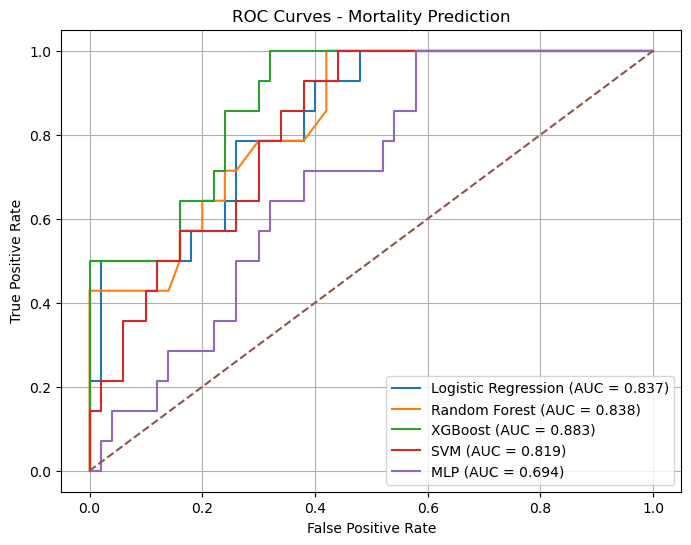

In [195]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

models_probs = {
    "Logistic Regression": y_prob2,
    "Random Forest": rf_prob,
    "XGBoost": xgb_prob,
    "SVM": svm_prob,
    "MLP": mlp_prob
}

plt.figure(figsize=(8, 6))

for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test2, probs)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Mortality Prediction")
plt.legend()
plt.grid()
plt.show()

In [199]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "SVM",
        "MLP"
    ],

    "ROC_AUC": [
        roc_auc_score(y_test2, y_prob2),
        roc_auc_score(y_test2, rf_prob),
        roc_auc_score(y_test2, xgb_prob),
        roc_auc_score(y_test2, svm_prob),
        roc_auc_score(y_test2, mlp_prob)
    ],

    "Accuracy": [
        accuracy_score(y_test2, y_pred2),
        accuracy_score(y_test2, rf_pred),
        accuracy_score(y_test2, xgb_pred),
        accuracy_score(y_test2, svm_pred),
        accuracy_score(y_test2, mlp_pred)
    ],

    "Precision": [
        precision_score(y_test2, y_pred2, zero_division=0),
        precision_score(y_test2, rf_pred, zero_division=0),
        precision_score(y_test2, xgb_pred, zero_division=0),
        precision_score(y_test2, svm_pred, zero_division=0),
        precision_score(y_test2, mlp_pred, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test2, y_pred2),
        recall_score(y_test2, rf_pred),
        recall_score(y_test2, xgb_pred),
        recall_score(y_test2, svm_pred),
        recall_score(y_test2, mlp_pred)
    ],

    "F1": [
        f1_score(y_test2, y_pred2),
        f1_score(y_test2, rf_pred),
        f1_score(y_test2, xgb_pred),
        f1_score(y_test2, svm_pred),
        f1_score(y_test2, mlp_pred)
    ]
})

results.sort_values("ROC_AUC", ascending=False)

,Model,ROC_AUC,Accuracy,Precision,Recall,F1
2,XGBoost,0.882857,0.84375,1.000,0.285714,0.444444
1,Random Forest,0.837857,0.78125,0.000,0.000000,0.000000
0,Logistic Regression,0.837143,0.87500,0.875,0.500000,0.636364
3,SVM,0.818571,0.81250,0.750,0.214286,0.333333
4,MLP,0.694286,0.78125,0.000,0.000000,0.000000


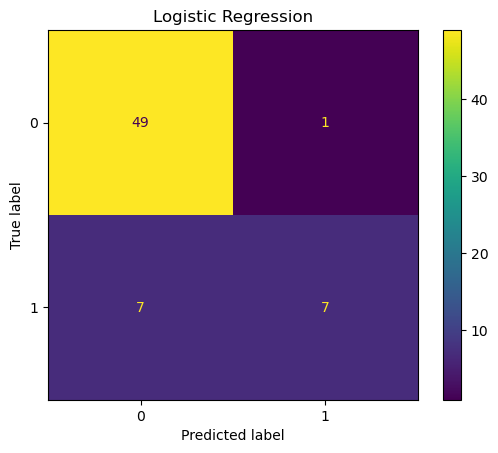

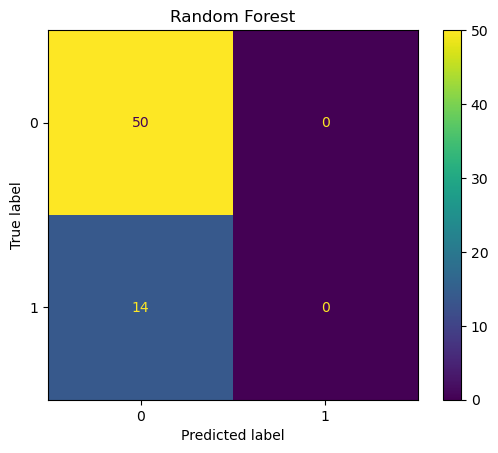

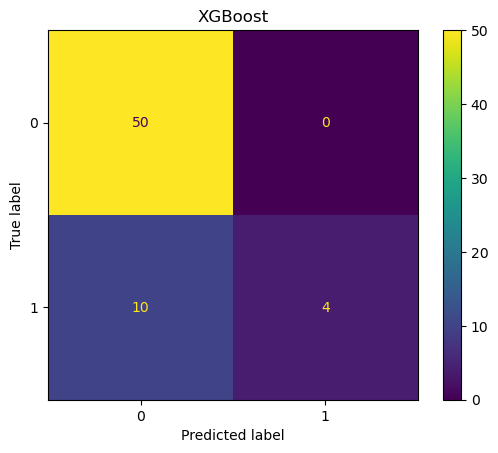

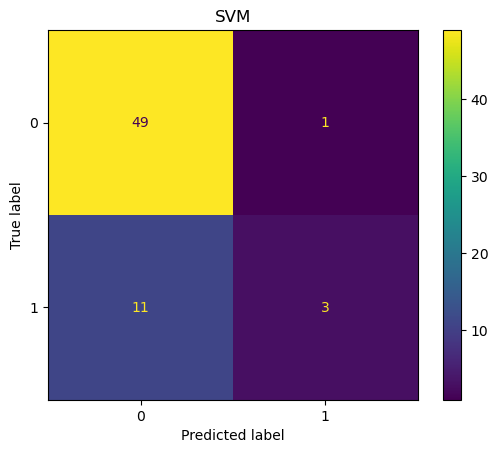

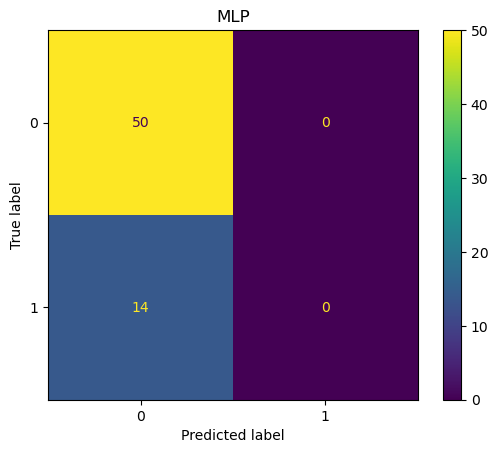

In [201]:
from sklearn.metrics import ConfusionMatrixDisplay

predictions = {
    "Logistic Regression": y_pred2,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "SVM": svm_pred,
    "MLP": mlp_pred
}

for name, preds in predictions.items():
    ConfusionMatrixDisplay.from_predictions(
        y_test2,
        preds
    )

    plt.title(name)
    plt.show()

In [203]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train2.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
22,Urea Nitrogen,0.145266
0,age,0.080537
2,II_mean,0.071874
19,Creatinine,0.062415
10,V5_mean,0.060035
5,II_max,0.059977
12,V5_min,0.059542
15,rr_mean,0.054317
13,V5_max,0.046891
1,gender,0.042960
